**Lab 4: FIR filters and envelopes**

The goal of this lab is to learn how to implement FIR filters in Python, and how we can use them to improve our synthesis.

In [14]:
import os
import numpy as np
import librosa
import IPython.display as ipd
from scipy import signal
import matplotlib.pyplot as plt

from util import load_audio, plot_signals, plot_spectrogram, plot_mean_spectrogram

**1. Overview of Filtering**

For this lab, we will define an FIR filter as a discrete-time system that converts an input signal $x[n]$ into an output signal $y[n]$ by means of the weighted summation:

$$
y[n] = \sum_{k=0}^M b_kx[n-k]
$$

The function *np.convolve()* is a generic function with which to implement FIR filters. The following code implements a three-point averaging system:

In [ ]:
fs = 1
x = [np.floor(x/10) for x in range(50)]
b = np.array([1.0/3, 1.0/3, 1.0/3])
y = np.convolve(b, x)

plot_signals([x, y], fs, name=['input x[n]', 'output y[n]'], mode='lines+markers')

1.1 Explain the filtering action of the 5-point averager by comparing the plot of the input $x[n]$ and the output $y[n]$. This filter might be called a “smoothing” filter. Note how the transitions from one level to another have been “smoothed.”

The 5-point averager, is used to smooth or average a signal. It operates by averaging the current sample and four previous samples from the input signal to create a smoother output. This filtering action reduces the impact of high-frequency noise and sharp transitions in the input. We can see this from the example above by noteching how the transitions last longer and have less of an angle of attack. It's an overall smoother graphic than the blue one.

*1.2* Define a function `averaging_filter(x, N)` which implements the N-points averaging filter using the `np.convolve` function.

In [15]:
import numpy as np

def averaging_filter(x, N):
    """
    Applies a N-point averaging filter to the input signal x

    Parameters
    ----------
    x : np.array
        The input signal in the form of a numpy array
    N : int
        The number of points used in N-point averaging filter

    Returns
    -------
    y : np.array
        The output of the filter
    """

    # Write your code here
    k = np.zeros(N)
    for i in range (N):
        k[i]=1 / N
    
    y = np.convolve(x,k)

    return y


1.3 Run the example above using the `averaging_filter` instead. Change the number N to different values and explain what happen.

In [ ]:
# Write your code here
fs = 1
x = [np.floor(x/10) for x in range(50)]

y = averaging_filter(x,4)

plot_signals([x, y], fs, name=['input x[n]', 'output y[n]'],mode='lines+markers')

First we analize for N=50. For different N values we can see that passed N=10 the input and output starts to take a value different of zero. This happens as the x array creates an array in a loop with value n/10, where it approximates to the floor, so passed N=10, it starts to take input values equal 1. From there, as long as N grows, the output average value grows gradually as the curve shows. Final value for N=50 will be 2 as the summatory of array x equals 100, divided by N=50.

Undertanding that, for different N values in the averaging_filter (x,N), the level of gradual growth/smoothness changes, as for a lower N it tends to look alike the input being less smooth, and for a large N, the graph is smoother taking a final value at 50 of 100/N

1.4 How would you classify this filter, as a low-pass o high-pass filter?

The n-point average filter is a low-pass filter as it smooths the signal for larger values in the x array, tending to attenuate high frequency components.

---

**2. Envelope detector**

Now we'll implement an envelope detector by concatenating two systems: a full-wave rectifier (absolute value) and the N-point averaging filter.

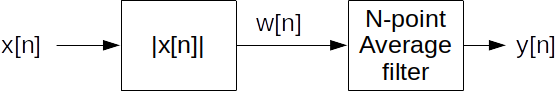

2.1 Define a function `envelope(x, N)` which applies an N-point averaging filter to the full-wave rectified signal and returns the output $y[n]$.

**Note 1**: to calculate the full-wave rectified signal check the `np.abs()` function.

**Note 2**: The output should have the same length as the input signal. Use 'same' mode (see [np.convolve](https://numpy.org/doc/stable/reference/generated/numpy.convolve.html) documentation).

In [16]:
import numpy as np

def envelope(x, N):
    """
    Extracts the envelope of the input signal x by concatenating a full-wave rectifier and an N-point averaging filter.

    Parameters
    ----------
    x : np.array
        The input signal in the form of a numpy array
    N : int
        The number of points used in N-point averaging filter

    Returns
    -------
    y : np.array
        The output of the system, i.e., the envelope of the signal x.
    """
    # write your code here
    
    w_n = np.abs(x)

    k = np.ones(N) / N
    
    y = np.convolve(w_n,k, mode='same')

    return y


2.2 Load your reference signal and calculate its envelope using the function you designed. Plot the reference signal and envelope in the same figure.

In [22]:
filepath = "sis1_group8/guitar2.wav"
ref, fs = load_audio(filepath)

env = envelope(ref,1000)
plot_signals([ref, env], fs, name=['reference', 'envelope'], mode='lines+markers')

2.3 Change the number N to get a good result. What happens when you change the number N?

We can see that the envelope looks more alike as the reference when using lower N values as there is less numbers/time period to compute the average and thus, tends to look alike as the reference value but less smooth. For larger values, the signal will become smoother.

2.4 Explain with your own words why this system achieves extracting the envelope. It might be useful to plot together the signals $x[n]$, $w[n]$ and $y[n]$.

In [ ]:
# Write your code here
filepath = "sis1_group8/guitar2.wav"
ref, fs = load_audio(filepath)

w = np.abs(ref)

y = envelope(ref,1000)
plot_signals([ref, w, y ], fs, name=['x[n]', 'w[n]','y[n]'], mode='lines+markers')


After plotting the graphs we can see the reference sound plotted as x[n] which contains positive and negative values for the frequency along time. For the w[n] as it corrects the reference with the absolute value, it will be the same figure but with only positive frequency values. Finally, plotting for y[n], the envelope, within all the process we can see a smoother signal with not that high values and only the positive ones.

2.5 Now let's apply this envelope to the synthesized signal. Copy the code from Lab3 Ex. 2.1 and generate the synthesized signal. Then multiply the synthesized signal by the envelope. Note that both signal and envelope should have the same length. You can define a time vector of the same length of the envelope to create the signal:

In [27]:
# Write your code here
#all these values are from the previous lab
weights = [1, 0.219, 0.093, 0.024, 0.00427, 0.0028, 0.0015, 0.00098, 0.00146, 0.0019, 0.00168] # Fill this list with the measured weights
def synthesize(f0, phi, Ak, t):
    y = 0
    for k in range(1, len(Ak) + 1):
        y += Ak[k-1] * np.cos(2*np.pi*k*f0*t + k*phi - (k-1)*np.pi/2)
    return y

from IPython.display import Audio
A = 0.2
f0 = 189.0
phi = -np.pi/4 + 0.0005
Ak = np.array(weights, dtype=float)
t = np.arange(len(ref)) / fs

y = synthesize(f0, phi, Ak, t)
y = A * y / np.max(np.abs(y))

N_env = 500
env_synth = envelope(ref, N_env)
final_signal = y * env_synth


2.6. Compare the spectrograms of the reference signal and the synthesized signal. What are the main differences?

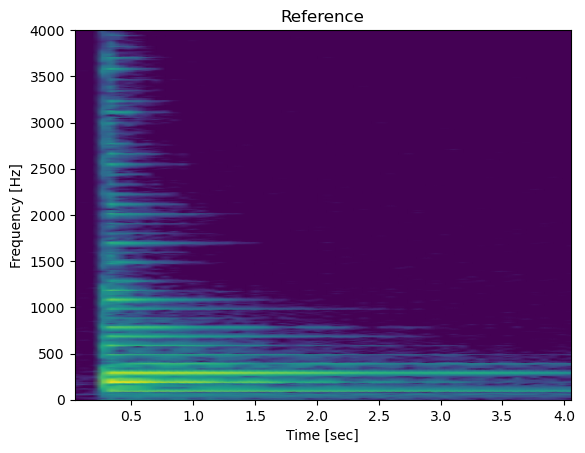

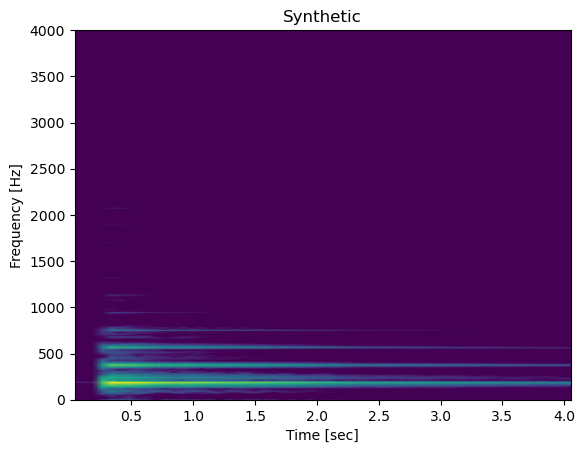

In [30]:
# Write your code here
from scipy.signal import spectrogram

N = 4000

ff, tt, S_ref = spectrogram(ref, fs=fs, nperseg=N, scaling='spectrum' )
ff_synt, tt_synt, S_synt = spectrogram( final_signal, fs=fs,  nperseg=N, scaling='spectrum')

plot_spectrogram(ff, tt, S_ref);  plt.ylim([0, 4000]); plt.title("Reference");  plt.show()
plot_spectrogram(ff_synt, tt_synt, S_synt); plt.ylim([0, 4000]); plt.title("Synthetic");  plt.show()

We can clearly see that the synthetic enveloped signal in the spectogram doesn't have high frequencies as when creating the synthetic there's alredy stablished an Amplitude define for all the signal, so that first attack period doesn't exist. With the full envelope process, the spectogram is constant through all the time period, concentrating in lower values.

2.7 Listen to the synthesized signal and compare it to the reference.



In [20]:
# Write your code here
print("Reference signal:")
display(Audio(ref, rate=fs))

Reference signal:


In [28]:
# Write your code here
print("Synth:")
display(Audio(final_signal, rate=fs))

Synth:
